<a href="https://colab.research.google.com/github/Maria-Manzini/FUTURE_DS_02-/blob/main/Task2_Churn_Analysis_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Customer Retention & Churn Analysis
## Future Interns | Data Science & Analytics Internship

### Project Overview
This notebook analyzes real Telco customer data to uncover:
- Overall churn rate and retention patterns
- Key drivers of customer churn
- Contract type and service impact on churn
- Actionable recommendations to reduce customer loss

**Tools Used:** Python, Pandas, Matplotlib
**Dataset:** Telco Customer Churn (Kaggle)
**Author:** Maria Manzini

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready ")

Libraries ready 


In [3]:
df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded ")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset loaded 
Shape: 7043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning
We check for missing values, fix data types, and prepare
the dataset for analysis.

In [4]:
print("=== DATA QUALITY CHECK ===")
print(f"\nShape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.drop_duplicates(inplace=True)

df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f"\nCleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Churn rate: {df['Churn_Binary'].mean()*100:.1f}%")
print(f"Total customers: {len(df):,}")
print("\nData cleaning complete ")

=== DATA QUALITY CHECK ===

Shape: (7043, 21)

Missing values:
Series([], dtype: int64)

Duplicate rows: 0

Cleaned dataset: 7032 rows × 22 columns
Churn rate: 26.6%
Total customers: 7,032

Data cleaning complete 


## Exploratory Analysis & Visualizations
We now explore churn patterns across contracts,
tenure, charges, and customer demographics.


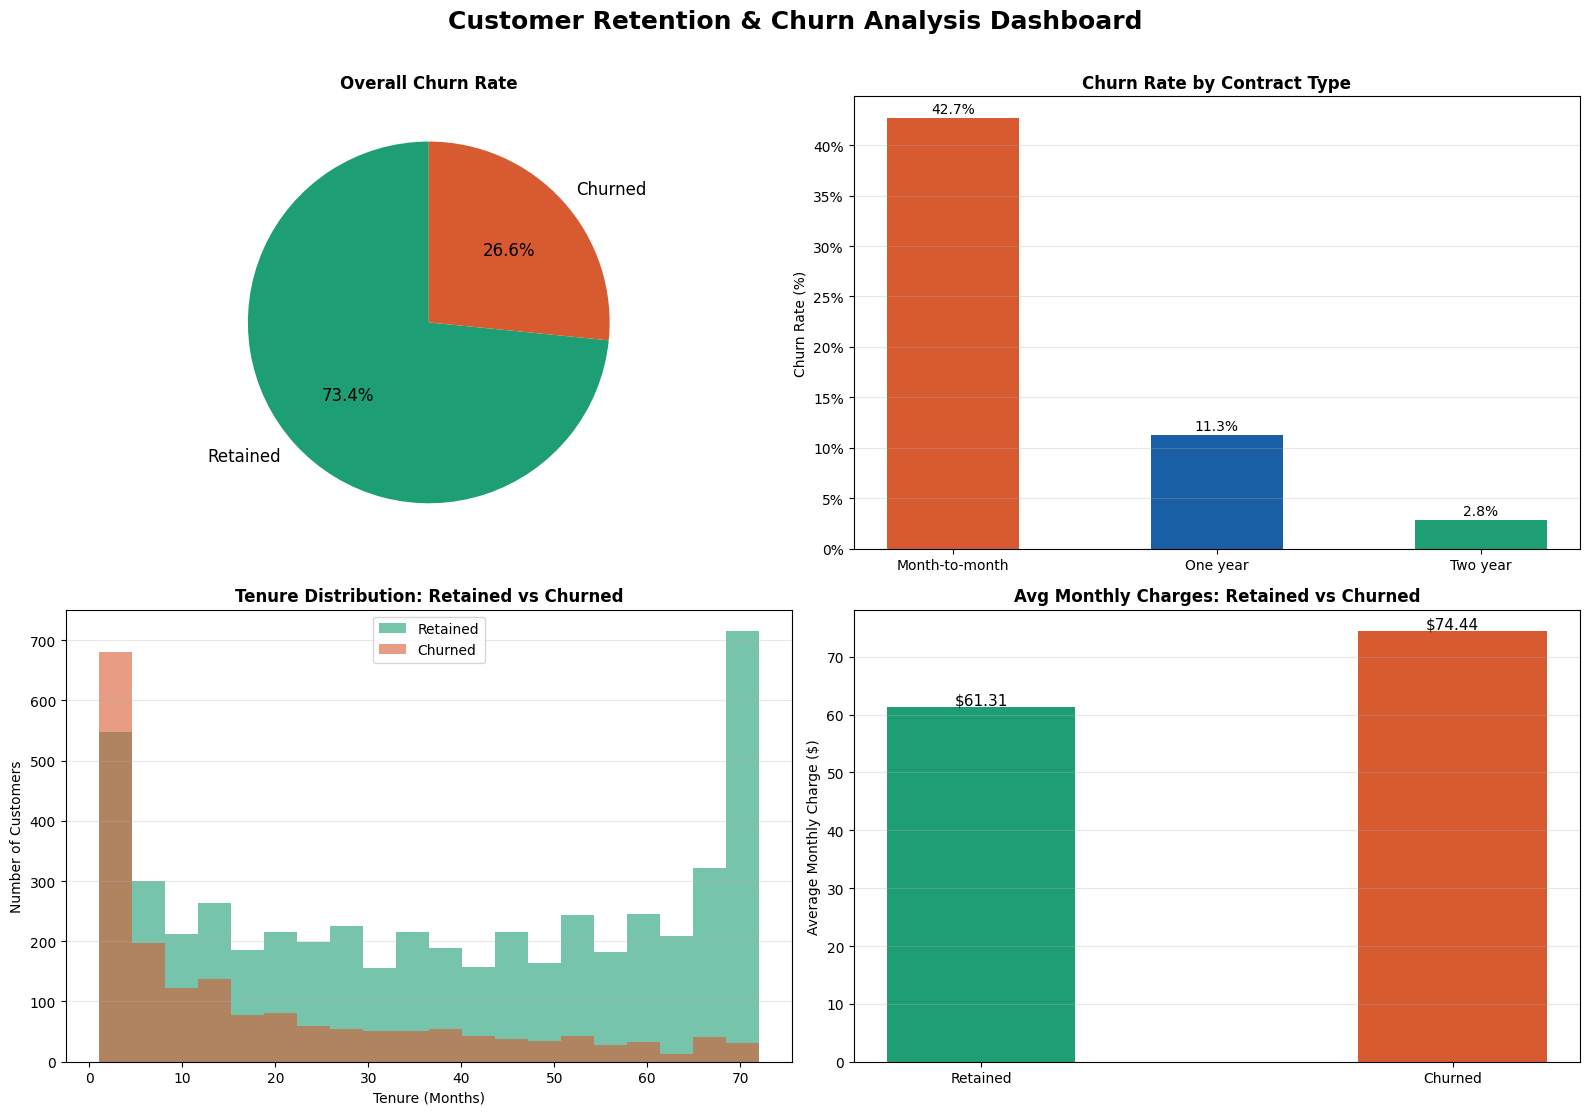

Dashboard saved 


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Customer Retention & Churn Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# Chart 1: Overall churn pie chart
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['Retained', 'Churned'],
              colors=['#1D9E75', '#D85A30'],
              autopct='%1.1f%%', startangle=90,
              textprops={'fontsize': 12})
axes[0,0].set_title('Overall Churn Rate', fontweight='bold')

# Chart 2: Churn by contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
bars = axes[0,1].bar(contract_churn.index, contract_churn.values,
                      color=['#D85A30', '#185FA5', '#1D9E75'], width=0.5)
axes[0,1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'{x:.0f}%'))
for bar, val in zip(bars, contract_churn.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=10)
axes[0,1].grid(axis='y', alpha=0.3)

# Chart 3: Tenure distribution by churn
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']
axes[1,0].hist(retained, bins=20, alpha=0.6,
               color='#1D9E75', label='Retained')
axes[1,0].hist(churned, bins=20, alpha=0.6,
               color='#D85A30', label='Churned')
axes[1,0].set_title('Tenure Distribution: Retained vs Churned',
                     fontweight='bold')
axes[1,0].set_xlabel('Tenure (Months)')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Chart 4: Monthly charges by churn
churn_charges = df.groupby('Churn')['MonthlyCharges'].mean()
bars2 = axes[1,1].bar(['Retained', 'Churned'],
                       churn_charges.values,
                       color=['#1D9E75', '#D85A30'], width=0.4)
axes[1,1].set_title('Avg Monthly Charges: Retained vs Churned',
                     fontweight='bold')
axes[1,1].set_ylabel('Average Monthly Charge ($)')
for bar, val in zip(bars2, churn_charges.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'${val:.2f}', ha='center', fontsize=11)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('churn_dashboard_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ")

In [6]:
print("=" * 50)
print("   CUSTOMER CHURN ANALYSIS INSIGHTS")
print("=" * 50)

churn_rate = df['Churn_Binary'].mean() * 100
print(f"\nOverall Churn Rate: {churn_rate:.1f}%")
print(f"Retention Rate: {100-churn_rate:.1f}%")
print(f"Total Customers Analyzed: {len(df):,}")

print("\nChurn Rate by Contract Type:")
for ct, rate in contract_churn.items():
    print(f"  {ct}: {rate:.1f}%")

print(f"\nAvg Tenure - Retained: {retained.mean():.1f} months")
print(f"Avg Tenure - Churned:  {churned.mean():.1f} months")

print(f"\nAvg Monthly Charge - Retained: ${churn_charges['No']:.2f}")
print(f"Avg Monthly Charge - Churned:  ${churn_charges['Yes']:.2f}")

print("\nRECOMMENDATIONS:")
print("1. Prioritize converting Month-to-Month customers")
print("   to annual or two-year contracts")
print("2. Offer loyalty discounts to customers")
print("   in their first 12 months — highest churn risk")
print("3. Review pricing for high monthly charge")
print("   customers as they churn at higher rates")
print("4. Build an early warning system to flag")
print("   at-risk customers before they churn")
print("=" * 50)

   CUSTOMER CHURN ANALYSIS INSIGHTS

Overall Churn Rate: 26.6%
Retention Rate: 73.4%
Total Customers Analyzed: 7,032

Churn Rate by Contract Type:
  Month-to-month: 42.7%
  One year: 11.3%
  Two year: 2.8%

Avg Tenure - Retained: 37.7 months
Avg Tenure - Churned:  18.0 months

Avg Monthly Charge - Retained: $61.31
Avg Monthly Charge - Churned:  $74.44

RECOMMENDATIONS:
1. Prioritize converting Month-to-Month customers
   to annual or two-year contracts
2. Offer loyalty discounts to customers
   in their first 12 months — highest churn risk
3. Review pricing for high monthly charge
   customers as they churn at higher rates
4. Build an early warning system to flag
   at-risk customers before they churn


## Conclusions

### What I Learned
- How to handle real telecom customer data with messy fields
- How to convert non-numeric columns for proper analysis
- How to visualize churn distributions using histograms
- How to identify the strongest drivers of customer churn

### Challenges Faced
- TotalCharges column was stored as a string and needed
  conversion to numeric before analysis
- Some rows had blank TotalCharges which required dropping
- Understanding which chart type best shows tenure distribution

### Key Takeaways
Month-to-Month contract customers churn at dramatically
higher rates than those on longer contracts. Early tenure
is the most critical period for retention intervention.
Customers paying higher monthly charges are also at
significantly greater risk of churning.